Compare functions:

$$
r_M = f_1(n_{\text{gag}}) = r_M \left( \left( 1 - \frac{l_{hg}^2}{2r_M^2} \right) \sqrt{1 - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)^2} - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right) \sqrt{1 - \left(1 - \frac{l_{hg}^2}{2r_M^2}\right)^2} \right)
$$

Versus:

$$
r_M = f_2(n_{\text{gag}}) = 2r_M \sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}} - \left( \frac{n_{\text{gag}}}{N_{\text{gag}}} \right)^2 }
$$

---
### Notes:
- The `np.maximum(inside_sqrt, 0)` is a safeguard to avoid invalid values inside the square root.

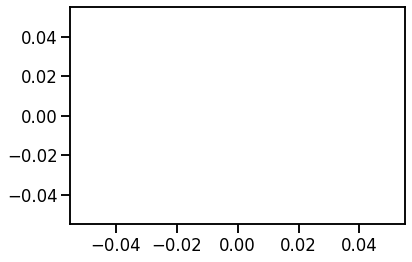

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.plot()
sns.set_context("talk")

def plot_expressions(n_gag_array, r_M, l_hg, N_gag):
    # Expression 1
    term1 = (1 - (l_hg**2) / (2 * r_M**2))
    sqrt1 = np.sqrt(1 - (1 - (2 * n_gag_array / N_gag))**2)
    term2 = (1 - (2 * n_gag_array / N_gag))
    sqrt2 = np.sqrt(1 - (1 - (l_hg**2) / (2 * r_M**2))**2)
    f2 = r_M * (term1 * sqrt1 - term2 * sqrt2)

    # Expression 2
    inside_sqrt = (n_gag_array / N_gag) - (n_gag_array / N_gag)**2
    inside_sqrt = np.maximum(inside_sqrt, 0)  # prevent negative inside sqrt due to numerical error
    f1 = 2 * r_M * np.sqrt(inside_sqrt)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.plot(n_gag_array, f2, label=r"$f_2(n_{\mathrm{gag}})$", linewidth=2)
    plt.plot(n_gag_array, f1, label=r"$f_1(n_{\mathrm{gag}})$", linewidth=2)
    plt.plot(n_gag_array, f1-f2, label=r"$f_1-f_2$", linestyle='--', linewidth=2)
    plt.xlabel(r"Number of gags", fontsize=22)
    plt.ylabel("Azimuthal radius (nm)", fontsize=22)
    plt.legend()
    plt.tight_layout()
    plt.savefig("Circumference_approximated_by_surface_area_vs_binding_sites.svg" ,format="svg")
    plt.savefig("Circumference_approximated_by_surface_area_vs_binding_sites.png" ,format="png")
    plt.show()


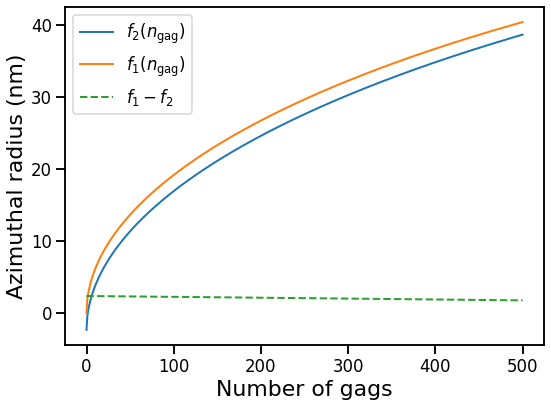

In [6]:
n_gag_array = np.linspace(0, 500, 500)
plot_expressions(n_gag_array, r_M=59, l_hg=2.35, N_gag=3700)

Note that the **difference looks almost like a constant** / slowly decays linearly.

# Why is it almost constant?

### Expression for $f_1$:

Start with the inside part:
Expand the square:
$$
\left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)^2 = 1 - \frac{4n_{\text{gag}}}{N_{\text{gag}}} + \frac{4n_{\text{gag}}^2}{N_{\text{gag}}^2}
$$

Thus:

$$
1 - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)^2 = \frac{4n_{\text{gag}}}{N_{\text{gag}}} \left( 1 - \frac{n_{\text{gag}}}{N_{\text{gag}}} \right)
$$

So:

$$
\sqrt{1 - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)^2} = 2\sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}} \left( 1 - \frac{n_{\text{gag}}}{N_{\text{gag}}} \right) }
$$

---
Also, define for convenience:

$$
\epsilon = \frac{l_{hg}^2}{2r_M^2}
\quad\quad \text{(small parameter)}
$$

Then:

- $1 - \epsilon$ is close to 1
- Also,
$$
\sqrt{1 - (1-\epsilon)^2} = \sqrt{1 - (1 - 2\epsilon + \epsilon^2)} \approx \sqrt{2\epsilon}
$$

---

Thus, $f_1$ becomes:

$$
f_1 = r_M \left( (1-\epsilon) \cdot 2 \sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}} \left(1-\frac{n_{\text{gag}}}{N_{\text{gag}}}\right) } - \left(1-\frac{2n_{\text{gag}}}{N_{\text{gag}}}\right) \cdot \sqrt{2\epsilon} \right)
$$

Expand:

$$
f_1 = 2r_M(1-\epsilon) \sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}}\left(1-\frac{n_{\text{gag}}}{N_{\text{gag}}}\right)} - r_M\left(1-\frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)\sqrt{2\epsilon}
$$

---

Now, the difference:

$$
f_2 - f_1
$$

Substituting:

$$
= 2r_M \sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}}\left(1-\frac{n_{\text{gag}}}{N_{\text{gag}}}\right)} - \left(2r_M(1-\epsilon) \sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}}\left(1-\frac{n_{\text{gag}}}{N_{\text{gag}}}\right)} - r_M\left(1-\frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)\sqrt{2\epsilon}\right)
$$

Expand:

$$
= 2r_M \sqrt{ \cdots } - 2r_M (1-\epsilon) \sqrt{ \cdots } + r_M\left(1-\frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)\sqrt{2\epsilon}
$$

Group terms:

$$
= 2r_M \epsilon \sqrt{ \frac{n_{\text{gag}}}{N_{\text{gag}}}\left(1-\frac{n_{\text{gag}}}{N_{\text{gag}}}\right)} + r_M\left(1-\frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)\sqrt{2\epsilon}
$$

---


Because $\epsilon$ is small, the **dominant contribution** to the difference is the second term:
$$
r_M \sqrt{2\epsilon} \left( 1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}} \right)
$$

Which slowly decays from $r_M \sqrt{2\epsilon}$ to zero.

---

### **Final approximate expression**:

$$
\boxed{f_2 - f_1 \approx r_M \sqrt{2\epsilon} \left( 1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}} \right)}
$$

where
$$
\epsilon = \frac{l_{hg}^2}{2r_M^2}
\quad \text{(iff small)}
$$